# Clustering No Jerárquico (K-Means)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [6]:
## Cargamos los datos

data_ii = pd.read_excel(r"dataset_didactico_machine_learning - ALUMNOS - copia.xlsx")

data_ii.head()

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


In [7]:
# Definimos que variable usar

X = data_ii[["Antiguedad_Meses", "Gasto_Mensual_Extra", "Asistencias_Mes", "Horas_Pico_Mes"]]

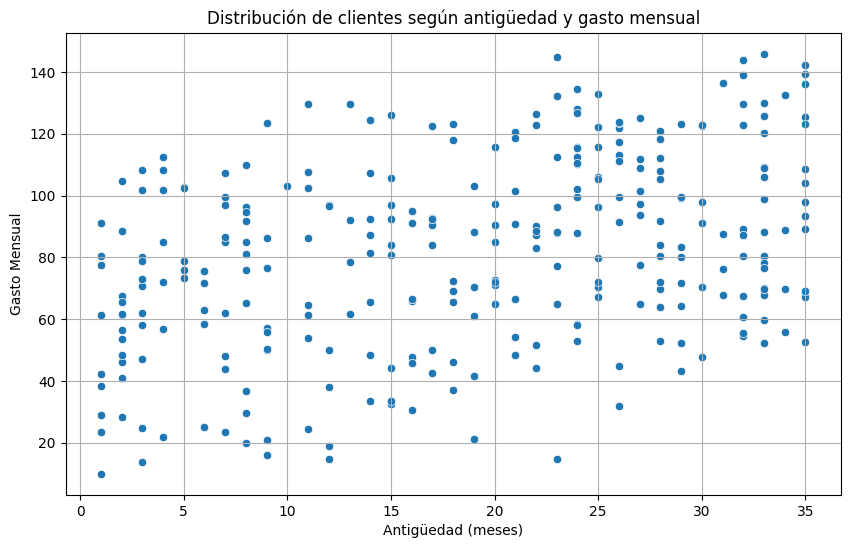

In [8]:
# Visualizar con scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x =data_ii["Antiguedad_Meses"],
    y =data_ii["Gasto_Mensual_Extra"]
)

plt.title("Distribución de clientes según antigüedad y gasto mensual")
plt.xlabel("Antigüedad (meses)")
plt.ylabel("Gasto Mensual")   
plt.grid(True)   
plt.show() 

In [9]:
# Normalizar las variables

scaler = StandardScaler()
datos_escalados = scaler.fit_transform(data_ii[["Antiguedad_Meses", "Gasto_Mensual_Extra"]])

In [10]:
print("\nDatos escalados:")
print(datos_escalados)


Datos escalados:
[[ 0.95602707 -0.57624142]
 [-0.36654002 -1.61536032]
 [-1.02782357  0.11191285]
 [ 0.20027445  1.28286269]
 [ 0.01133629  0.70551178]
 [ 0.3892126   2.07422194]
 [-0.74441633  0.15335587]
 [-0.74441633  1.57713578]
 [ 0.48368168  1.11873573]
 [ 0.48368168  0.93474621]
 [-1.50016896 -1.13669885]
 [ 0.29474352 -0.98453791]
 [-1.59463804 -0.46655699]
 [ 0.48368168  1.1103018 ]
 [ 1.05049615  0.31066064]
 [-1.59463804 -1.75008247]
 [ 0.20027445 -0.89880507]
 [ 1.33390338 -0.04399282]
 [-0.64994726  0.49785451]
 [ 0.29474352  0.27794577]
 [ 0.57815076 -0.47387404]
 [ 0.76708891 -0.55491031]
 [ 0.86155799 -0.38902182]
 [-0.27207094 -1.67988615]
 [-0.36654002 -1.58706067]
 [-1.50016896 -0.36115133]
 [-1.12229265  0.58649169]
 [ 0.20027445  0.3036787 ]
 [-0.93335449 -1.04290407]
 [-0.08313279  1.19410505]
 [-1.40569988 -0.81831007]
 [ 0.57815076  1.11827785]
 [-0.4610091  -0.00482248]
 [-0.93335449 -0.80428389]
 [ 0.67261984  0.59101977]
 [-1.59463804 -1.16250169]
 [ 0.10580

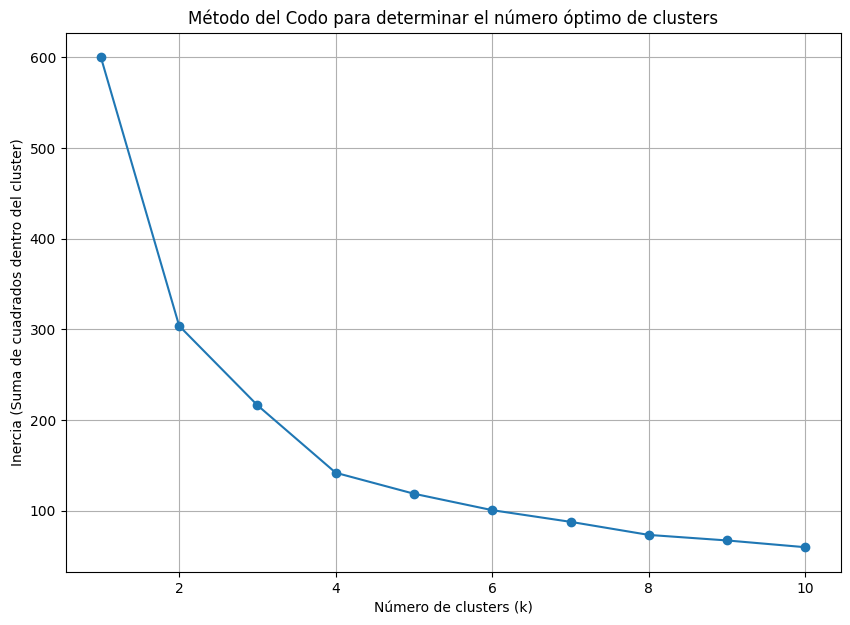

In [11]:
# Método del codo para determinar el número óptimo de clusters

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmean = KMeans(n_clusters=k, random_state=42)
    kmean.fit(datos_escalados)
    inertia.append(kmean.inertia_)
    
# Visualización del método del codo

plt.figure(figsize=(10, 7))
plt.plot(K_range, inertia, marker='o')
plt.title("Método del Codo para determinar el número óptimo de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (Suma de cuadrados dentro del cluster)")
plt.grid()
plt.show()


Centroides de cada cluster (en el espacio normalizado):
[[ 0.74726207  1.17175291]
 [-0.95434762  0.21524054]
 [ 0.7923539  -0.32918324]
 [-0.98291204 -1.3458942 ]]

Silhouette Score: 0.4090


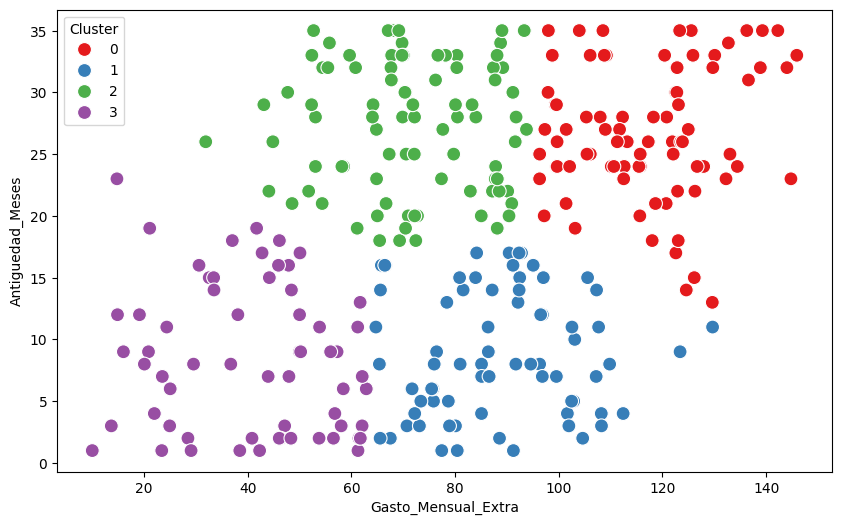

In [13]:
# Entrenamiento del modelo final

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(datos_escalados)

# Añadimos el cluster al dataframe original
data_ii['Cluster'] = clusters

# Ver centroides de cada cluster
print("\nCentroides de cada cluster (en el espacio normalizado):")
print(kmeans.cluster_centers_)

# Scoring de solhoutte

score = silhouette_score(datos_escalados, clusters)
print(f"\nSilhouette Score: {score:.4f}")


# Visualización del scatter plot con los clusters
plt.figure(figsize=(10, 6))
# Añadir la columna de cluster a data_ii y graficar
data_ii['Cluster'] = clusters

sns.scatterplot(
    x=data_ii["Gasto_Mensual_Extra"],
    y=data_ii["Antiguedad_Meses"],
    hue=data_ii["Cluster"],
    palette="Set1",
    s=100
)

plt.show()